# Two-Stage DS-WGAN Procedure
**Athey, Imbens, Metzger & Munro (2020)**

Two-stage conditional WGAN using `wgan_jax.py`:

- **Stage 1**: Learn $X \mid W$ (covariates conditional on treatment)
- **Stage 2**: Learn $Y \mid X, W$ (outcome conditional on covariates and treatment)
- **Generation**: Sample $\tilde{X}$ from Stage 1, then $\tilde{Y}$ from Stage 2 conditioned on $(\tilde{X}, W)$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wgan_jax import WGAN, compare_dfs

## 1. Synthetic DGP

5 covariates (`age`, `income`, `education`, `married`, `urban`), binary treatment $W$ with selection on observables, outcome $Y$ with heterogeneous treatment effects. True ATT $\approx 2.5$.

In [10]:
np.random.seed(42)
N = 3000

# Covariates (correlated)
age = np.random.normal(35, 8, N).clip(18, None)
income = np.exp(0.5 + 0.02 * age + np.random.normal(0, 0.4, N))  # log-normal, correlated with age
education = (12 + 0.3 * (age - 35) / 8 + np.random.normal(0, 2, N)).clip(6, 22)
married = (np.random.uniform(size=N) < 1 / (1 + np.exp(-(0.05 * age - 2)))).astype(float)
urban = np.random.binomial(1, 0.6, N).astype(float)

# Treatment assignment (selection on observables)
age_std = (age - age.mean()) / age.std()
inc_std = (income - income.mean()) / income.std()
edu_std = (education - education.mean()) / education.std()
logit_w = -1 + 0.3 * age_std + 0.2 * inc_std - 0.1 * edu_std + 0.3 * married
W = np.random.binomial(1, 1 / (1 + np.exp(-logit_w))).astype(float)

# Outcome with heterogeneous treatment effect
tau = 2.5 + 0.5 * edu_std - 0.3 * inc_std  # individual treatment effect
Y = (5 + 0.8 * age_std + 1.5 * inc_std - 0.3 * edu_std**2
     + 2 * married + urban + tau * W + np.random.normal(0, 1, N))

TRUE_ATT = tau[W == 1].mean()

df = pd.DataFrame({
    "age": age, "income": income, "education": education,
    "married": married, "urban": urban, "W": W, "Y": Y,
})

print(f"N = {N}, treatment rate = {W.mean():.2f}, True ATT = {TRUE_ATT:.3f}")
df.describe()

N = 3000, treatment rate = 0.32, True ATT = 2.424


,age,income,education,married,urban,W,Y
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,35.297893,3.607994,12.019522,0.454667,0.593667,0.315000,6.988512
std,7.789252,1.613688,2.069242,0.498024,0.491230,0.464593,2.965248
min,18.000000,0.834044,6.000000,0.000000,0.000000,0.000000,-1.236148
25%,29.979671,2.445162,10.599072,0.000000,0.000000,0.000000,4.807200
50%,35.194919,3.311338,11.992039,0.000000,1.000000,0.000000,6.803215
75%,40.388727,4.378528,13.429788,1.000000,1.000000,1.000000,9.000433
max,66.409902,13.454187,19.210293,1.000000,1.000000,1.000000,17.219852


## 2. Stage 1: X | W

Train a WGAN to generate the 5 covariates conditional on treatment status $W$. One shared generator $g(Z \mid W)$ and one shared critic learn both treatment groups simultaneously.

In [3]:
wgan_stage1 = WGAN(
    df=df,
    continuous_vars=["age", "income", "education"],
    categorical_vars=["married", "urban"],
    conditioning_vars=["W"],
    continuous_lower_bounds={"age": 18, "income": 0, "education": 6},
    continuous_upper_bounds={"education": 22},
    seed=0,
)

WGAN initialized: d_x=7 (cont=3, cat=4), d_cond=1, noise_dim=7


In [5]:
history1 = wgan_stage1.train(max_epochs=600, batch_size=256, print_every=25)

epoch     0 | WD_train   0.3412 | WD_test   0.1427 | 2s
epoch    25 | WD_train   0.1149 | WD_test   0.1354 | 11s
epoch    50 | WD_train   0.3377 | WD_test   0.2793 | 11s
epoch    75 | WD_train   0.3543 | WD_test   0.2422 | 11s
epoch   100 | WD_train   0.3318 | WD_test   0.4839 | 11s
epoch   125 | WD_train   0.1421 | WD_test   0.4202 | 11s
epoch   150 | WD_train   0.1360 | WD_test  -0.0217 | 11s
epoch   175 | WD_train   0.1295 | WD_test   0.5271 | 11s
epoch   200 | WD_train   0.1952 | WD_test   0.1971 | 11s
epoch   225 | WD_train   0.1310 | WD_test   0.2796 | 11s
epoch   250 | WD_train   0.1055 | WD_test   0.1656 | 11s
epoch   275 | WD_train   0.3059 | WD_test   0.4720 | 11s
epoch   300 | WD_train   0.1572 | WD_test   0.6080 | 11s
epoch   325 | WD_train   0.0577 | WD_test   0.0698 | 11s
epoch   350 | WD_train   0.1985 | WD_test   0.1314 | 11s
epoch   375 | WD_train   0.0460 | WD_test   0.0080 | 11s
epoch   400 | WD_train   0.1486 | WD_test  -0.3083 | 11s
epoch   425 | WD_train   0.2284 

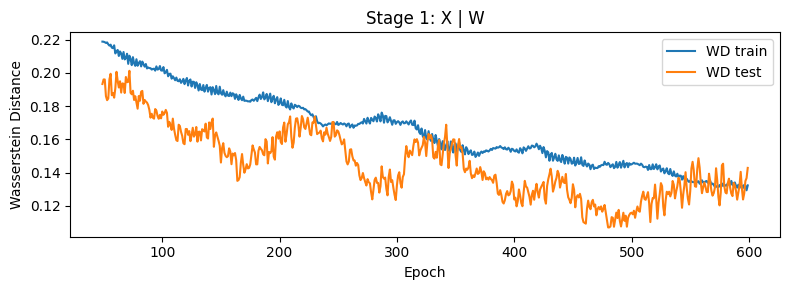

In [6]:
plt.figure(figsize=(8, 3))
plt.plot(pd.Series(history1["wd_train"]).rolling(50).mean(), label="WD train")
plt.plot(pd.Series(history1["wd_test"]).rolling(50).mean(), label="WD test")
plt.xlabel("Epoch"); plt.ylabel("Wasserstein Distance")
plt.title("Stage 1: X | W")
plt.legend(); plt.tight_layout(); plt.show()

------------- comparison of means -------------
W            0.0           1.0       
source      fake   real   fake   real
urban       0.58   0.59   0.57   0.60
education  12.19  12.01  12.11  12.04
income      3.29   3.41   3.87   4.04
age        32.80  34.26  35.44  37.57
married     0.41   0.42   0.51   0.53

------------- comparison of stds  -------------
W           0.0         1.0      
source     fake  real  fake  real
urban      0.49  0.49  0.50  0.49
education  1.93  2.03  2.09  2.14
income     1.41  1.46  1.72  1.82
age        7.85  7.70  7.33  7.51
married    0.49  0.49  0.50  0.50



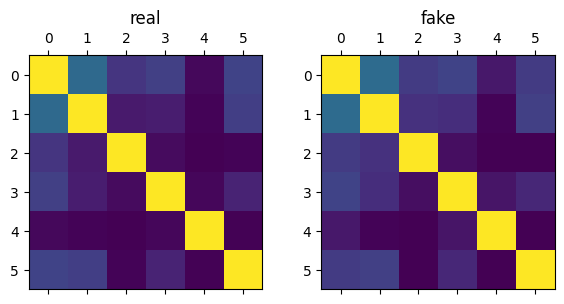

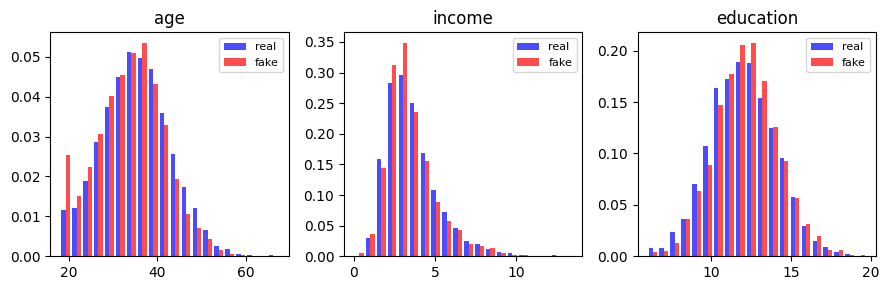

In [11]:
df_stage1 = wgan_stage1.generate(df[["W"]], seed=0)

compare_dfs(
    df[["age", "income", "education", "married", "urban", "W"]],
    df_stage1,
    histogram=dict(variables=["age", "income", "education"], nrow=1, ncol=3),
    table_groupby=["W"],
)

## 3. Stage 2: Y | X, W

Train a second WGAN to generate the scalar outcome $Y$ conditional on all covariates and treatment: $g(Z \mid X, W)$.

In [12]:
wgan_stage2 = WGAN(
    df=df,
    continuous_vars=["Y"],
    categorical_vars=[],
    conditioning_vars=["age", "income", "education", "married", "urban", "W"],
    seed=1,
)

WGAN initialized: d_x=1 (cont=1, cat=0), d_cond=6, noise_dim=1


In [13]:
history2 = wgan_stage2.train(max_epochs=600, batch_size=256, print_every=25)

epoch     0 | WD_train   0.3925 | WD_test   0.5318 | 2s
epoch    25 | WD_train   0.0774 | WD_test   0.1922 | 11s
epoch    50 | WD_train   0.1072 | WD_test   0.1155 | 11s
epoch    75 | WD_train   0.1249 | WD_test   0.0471 | 11s
epoch   100 | WD_train   0.0506 | WD_test   0.1417 | 11s
epoch   125 | WD_train   0.0227 | WD_test   0.0471 | 11s
epoch   150 | WD_train   0.0299 | WD_test   0.1679 | 11s
epoch   175 | WD_train   0.0601 | WD_test   0.0583 | 11s
epoch   200 | WD_train   0.0184 | WD_test   0.0657 | 11s
epoch   225 | WD_train   0.0624 | WD_test  -0.0081 | 11s
epoch   250 | WD_train   0.0520 | WD_test   0.0149 | 11s
epoch   275 | WD_train   0.0516 | WD_test  -0.0034 | 11s
epoch   300 | WD_train   0.0588 | WD_test  -0.0213 | 11s
epoch   325 | WD_train   0.0656 | WD_test  -0.0244 | 11s
epoch   350 | WD_train   0.0672 | WD_test  -0.0312 | 11s
epoch   375 | WD_train   0.0710 | WD_test  -0.0033 | 11s
epoch   400 | WD_train   0.0730 | WD_test  -0.0084 | 11s
epoch   425 | WD_train   0.0771 

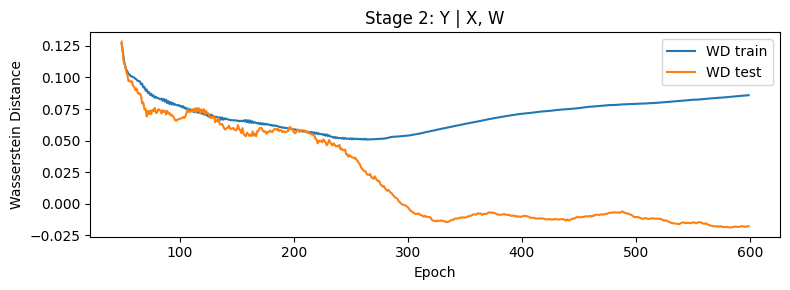

In [14]:
plt.figure(figsize=(8, 3))
plt.plot(pd.Series(history2["wd_train"]).rolling(50).mean(), label="WD train")
plt.plot(pd.Series(history2["wd_test"]).rolling(50).mean(), label="WD test")
plt.xlabel("Epoch"); plt.ylabel("Wasserstein Distance")
plt.title("Stage 2: Y | X, W")
plt.legend(); plt.tight_layout(); plt.show()

------------- comparison of means -------------
W       0.0        1.0      
source fake real  fake  real
Y       5.9  5.9  9.32  9.36

------------- comparison of stds  -------------
W        0.0        1.0      
source  fake real  fake  real
Y       2.48  2.5  2.49  2.48



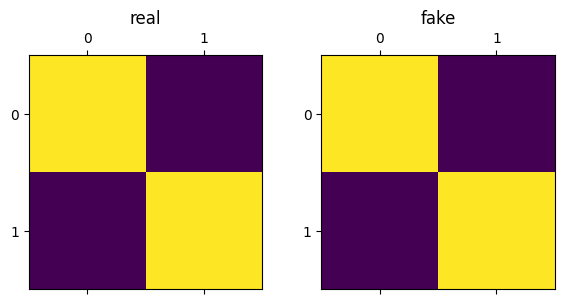

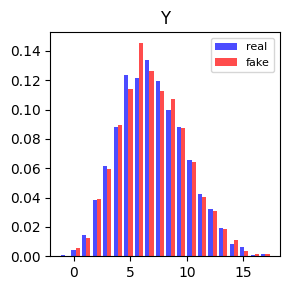

In [15]:
df_stage2 = wgan_stage2.generate(
    df[["age", "income", "education", "married", "urban", "W"]], seed=0
)

compare_dfs(
    df[["Y", "W"]],
    df_stage2[["Y", "W"]],
    histogram=dict(variables=["Y"], nrow=1, ncol=1),
    table_groupby=["W"],
)

## 4. Full DS-WGAN Generation Pipeline

Chain both stages: sample $\tilde{X}$ from Stage 1, then $\tilde{Y}$ from Stage 2 conditioned on $(\tilde{X}, W)$.

In [16]:
COVARIATE_COLS = ["age", "income", "education", "married", "urban"]
COND_STAGE2 = COVARIATE_COLS + ["W"]


def generate_ds_wgan(wgan_s1, wgan_s2, df_w, seed=0):
    """Two-stage DS-WGAN generation.

    1. Generate X_tilde | W from Stage 1
    2. Generate Y_tilde | X_tilde, W from Stage 2
    """
    df_x = wgan_s1.generate(df_w, seed=seed)
    df_y = wgan_s2.generate(df_x[COND_STAGE2], seed=seed + 1)
    return df_y

------------- comparison of means -------------
W            0.0           1.0       
source      fake   real   fake   real
urban       0.59   0.59   0.61   0.60
education  12.22  12.01  12.19  12.04
income      3.28   3.41   3.96   4.04
age        32.83  34.26  35.35  37.57
married     0.42   0.42   0.50   0.53
Y           5.62   5.90   9.07   9.36

------------- comparison of stds  -------------
W           0.0         1.0      
source     fake  real  fake  real
urban      0.49  0.49  0.49  0.49
education  2.00  2.03  2.08  2.14
income     1.42  1.46  1.78  1.82
age        7.85  7.70  7.08  7.51
married    0.49  0.49  0.50  0.50
Y          2.47  2.50  2.38  2.48



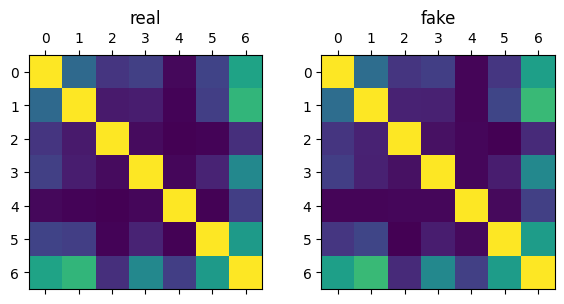

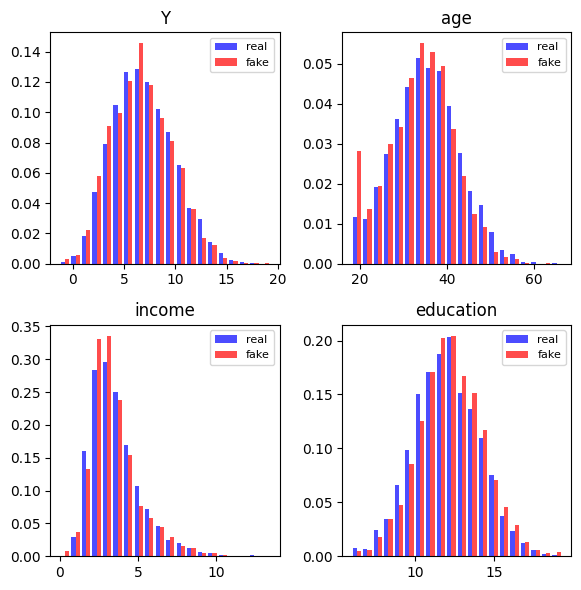

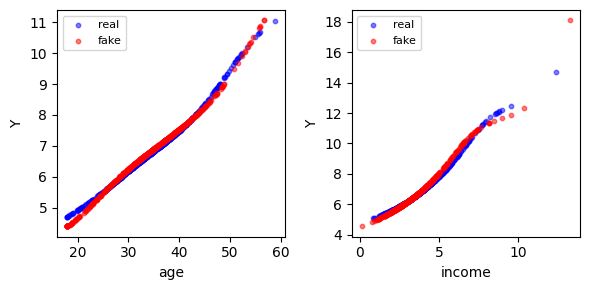

In [17]:
df_syn = generate_ds_wgan(wgan_stage1, wgan_stage2, df[["W"]], seed=42)

compare_dfs(
    df, df_syn,
    histogram=dict(variables=["Y", "age", "income", "education"], nrow=2, ncol=2),
    scatterplot=dict(x=["age", "income"], y=["Y"], samples=500, smooth=0.5),
    table_groupby=["W"],
)

## 5. Population ATT from the Generator

For treated units, hold Stage 1 covariates $\tilde{X}$ fixed and re-run Stage 2 with $W$ flipped to 0 to get counterfactual $\tilde{Y}(0)$. The population ATT is $\mathbb{E}[\tilde{Y}(1) - \tilde{Y}(0) \mid W=1]$.

In [18]:
# Generate a large synthetic population via the full pipeline
N_pop = 50_000
w_pop = np.random.choice(df["W"].values, N_pop, replace=True)
df_pop = generate_ds_wgan(wgan_stage1, wgan_stage2, pd.DataFrame({"W": w_pop}), seed=0)

# For treated units: Y(1) is already generated. Get Y(0) by flipping W in Stage 2 only.
treated_mask = df_pop["W"] == 1
df_treated = df_pop[treated_mask].copy()

# Y(1)
y1 = df_treated["Y"].values

# Y(0): same covariates, W flipped to 0
df_cf_cond = df_treated[COND_STAGE2].copy()
df_cf_cond["W"] = 0.0
df_cf = wgan_stage2.generate(df_cf_cond, seed=99)
y0 = df_cf["Y"].values

pop_att = y1.mean() - y0.mean()
print(f"Generator population ATT: {pop_att:.3f}")
print(f"True ATT:                 {TRUE_ATT:.3f}")

Generator population ATT: 2.401
True ATT:                 2.424


## 6. Monte Carlo Experiment

Draw repeated synthetic datasets from the DS-WGAN, apply three ATT estimators (OLS, IPW, Doubly Robust), and compare their sampling distributions against the generator's population ATT.

In [19]:
from sklearn.linear_model import LinearRegression, LogisticRegression


def att_ols(Y, W, V):
    """OLS regression adjustment."""
    Xmat = np.column_stack([W, V])
    return LinearRegression().fit(Xmat, Y).coef_[0]


def att_ipw(Y, W, V):
    """Inverse propensity weighting."""
    ps = LogisticRegression(max_iter=1000).fit(V, W).predict_proba(V)[:, 1]
    ps = np.clip(ps, 0.05, 0.95)
    treated = W == 1
    w0 = (ps / (1 - ps))[~treated]
    return Y[treated].mean() - np.average(Y[~treated], weights=w0)


def att_dr(Y, W, V):
    """Doubly robust (AIPW)."""
    ps = LogisticRegression(max_iter=1000).fit(V, W).predict_proba(V)[:, 1]
    ps = np.clip(ps, 0.05, 0.95)
    treated = W == 1
    m1 = LinearRegression().fit(V[treated], Y[treated])
    m0 = LinearRegression().fit(V[~treated], Y[~treated])
    mu1, mu0 = m1.predict(V), m0.predict(V)
    att = (
        (W * (Y - mu0) / W.mean()
         - (1 - W) * ps / (1 - ps) * (Y - mu0) / W.mean()).mean()
        + (mu1 - mu0)[treated].mean()
    )
    return att

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
n_mc = 200
sample_size = 500
results = {"OLS": [], "IPW": [], "DR": []}

for r in range(n_mc):
    w_mc = np.random.choice(df["W"].values, sample_size, replace=True)
    df_mc = generate_ds_wgan(
        wgan_stage1, wgan_stage2,
        pd.DataFrame({"W": w_mc}),
        seed=r * 10,
    )

    Y_mc = df_mc["Y"].values
    W_mc = df_mc["W"].values
    X_mc = df_mc[COVARIATE_COLS].values

    results["OLS"].append(att_ols(Y_mc, W_mc, X_mc))
    results["IPW"].append(att_ipw(Y_mc, W_mc, X_mc))
    results["DR"].append(att_dr(Y_mc, W_mc, X_mc))

    if (r + 1) % 50 == 0:
        print(f"MC replications: {r + 1}/{n_mc}")

In [ ]:
print(f"\n{'':>6} {'Bias':>8} {'Std':>8} {'RMSE':>8}")
for name, vals in results.items():
    vals = np.array(vals)
    bias = vals.mean() - pop_att
    std = vals.std()
    rmse = np.sqrt(bias**2 + std**2)
    print(f"{name:>6} {bias:>8.3f} {std:>8.3f} {rmse:>8.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, vals in results.items():
    ax.hist(vals, bins=30, alpha=0.4, label=name, density=True)
ax.axvline(pop_att, color="k", ls="--", lw=2, label=f"Pop ATT = {pop_att:.2f}")
ax.axvline(TRUE_ATT, color="gray", ls=":", lw=2, label=f"True ATT = {TRUE_ATT:.2f}")
ax.legend()
ax.set_xlabel("Estimated ATT")
ax.set_title("MC Distribution of ATT Estimators (DS-WGAN DGP)")
plt.tight_layout(); plt.show()